# Imports


In [3]:
import pandas as pd
import numpy as np
import networkx as nx          # the graph library (main tool)
import itertools               # for generating pairs
import collections             # for counting co-occurrences
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use('ggplot')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded')

All libraries loaded


# Data Loading

In [4]:
df = pd.read_csv('../data/data/final_dataset2.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
df.head(10)

Shape: (20000, 6)
Columns: ['Order_ID', 'Restaurant', 'User_Type', 'Time', 'Items_List', 'Items']



,Order_ID,Restaurant,User_Type,Time,Items_List,Items
0,1,Bazooka,family,night,"['Crispy Sandwich', 'Mozzarella Sticks', 'Juice']","Crispy Sandwich, Mozzarella Sticks, Juice"
1,2,Bazooka,student,afternoon,"['Crispy Sandwich', 'Mozzarella Sticks', 'Cola']","Crispy Sandwich, Mozzarella Sticks, Cola"
2,3,Bazooka,diet,night,['Beef Burger'],Beef Burger
3,4,Dominos,student,afternoon,"['BBQ Chicken Pizza', 'Coke', 'Chicken Ranch']","BBQ Chicken Pizza, Coke, Chicken Ranch"
4,5,Dominos,student,night,"['BBQ Chicken Pizza', 'Potato Wedges', 'Coke',...","BBQ Chicken Pizza, Potato Wedges, Coke, Sprite"
5,6,PizzaHut,student,night,"['Chicken Ranch', 'Garlic Bread', 'Mirinda']","Chicken Ranch, Garlic Bread, Mirinda"
6,7,McDonalds,student,morning,"['Quarter Pounder', 'Fanta']","Quarter Pounder, Fanta"
7,8,Dominos,student,morning,"['BBQ Chicken Pizza', 'Sprite']","BBQ Chicken Pizza, Sprite"
8,9,Zooba,diet,night,['Koshary'],Koshary
9,10,SpaghettiFactory,family,afternoon,"['Alfredo Pasta', 'Garlic Bread', 'Soda']","Alfredo Pasta, Garlic Bread, Soda"


In [5]:
# Parse the Items column into actual Python lists
df['Items_Parsed'] = df['Items'].apply(
    lambda x: [item.strip() for item in str(x).split(',') if item.strip()]
)
df['Item_Count'] = df['Items_Parsed'].apply(len)

# Count how often each meal appears across all orders
all_items = [item for sublist in df['Items_Parsed'] for item in sublist]
item_freq = collections.Counter(all_items)

print(f'Total orders:             {len(df):,}')
print(f'Orders with 2+ items:     {(df["Item_Count"] >= 2).sum():,}')
print(f'Orders with 1 item only:  {(df["Item_Count"] == 1).sum():,}')
print(f'Avg items per order:      {df["Item_Count"].mean():.2f}')
print(f'Unique meals:             {len(item_freq)}')
print(f'Unique restaurants:       {df["Restaurant"].nunique()}')
print()
print('Top 10 most ordered meals (raw count):')
for meal, count in item_freq.most_common(10):
    print(f'  {meal}: {count:,}')

Total orders:             20,000
Orders with 2+ items:     14,812
Orders with 1 item only:  5,188
Avg items per order:      3.89
Unique meals:             46
Unique restaurants:       10

Top 10 most ordered meals (raw count):
  Pepsi: 22,149
  Fries: 9,911
  Juice: 3,422
  Pepperoni Pizza: 3,130
  Thickburger: 2,058
  Shawarma: 1,964
  Garlic Bread: 1,948
  Koshary: 1,890
  Coke: 1,881
  Potato Wedges: 1,678


#  Building the Meal Co-occurrence Graph

#### If Burger and Fries appear in the same order => draw an edge between them. If it happens 500 times => that edge has weight 500.

In [6]:
# Only keep orders with 2+ items
multi_item_orders = df[df['Item_Count'] >= 2]['Items_Parsed'].tolist()
print(f'Orders used for graph: {len(multi_item_orders):,}')

# Count every pair that appears together in the same order
co_occur = collections.Counter()

for transaction in multi_item_orders:
    for a, b in itertools.combinations(sorted(transaction), 2):
        co_occur[(a, b)] += 1

print(f'Unique meal pairs found: {len(co_occur):,}')
print()
print('Top 10 most co-ordered pairs:')
for pair, count in co_occur.most_common(10):
    print(f'  {pair[0]}  +  {pair[1]}:  {count} times')

Orders used for graph: 14,812
Unique meal pairs found: 913

Top 10 most co-ordered pairs:
  Pepsi  +  Pepsi:  621837 times
  Pepsi  +  Potato Wedges:  29068 times
  Pepperoni Pizza  +  Pepsi:  23261 times
  Pepsi  +  Wings:  18359 times
  Chicken Bucket  +  Pepsi:  18114 times
  Mountain Dew  +  Pepsi:  17754 times
  Mirinda  +  Pepsi:  17241 times
  Pepsi  +  Zinger:  16776 times
  Beef Burger  +  Pepsi:  15053 times
  McChicken  +  Pepsi:  14688 times


##### note:  possible pairs => (Burger, Fries), (Burger, Pepsi), (Fries, Pepsi). We sort them first so (Fries, Burger) and (Burger, Fries) don't get counted as two different pairs.

In [7]:
# Build the graph
G = nx.Graph()

for (a, b), weight in co_occur.items():
    G.add_edge(a, b, weight=weight)

# Basic stats
degrees = dict(G.degree())

print('=== Graph Statistics ===')
print(f'Nodes (meals):     {G.number_of_nodes()}')
print(f'Edges (pairs):     {G.number_of_edges()}')
print(f'Density:           {nx.density(G):.4f}')
print(f'Is connected:      {nx.is_connected(G)}')
print()
print('Top 10 most connected meals (by degree):')
for meal, deg in sorted(degrees.items(), key=lambda x: -x[1])[:10]:
    print(f'  {meal}: {deg} connections')

=== Graph Statistics ===
Nodes (meals):     46
Edges (pairs):     913
Density:           0.8821
Is connected:      True

Top 10 most connected meals (by degree):
  Juice: 47 connections
  Coke: 47 connections
  Fries: 47 connections
  Pepsi: 47 connections
  Pepperoni Pizza: 47 connections
  Garlic Bread: 46 connections
  Koshary: 46 connections
  Shawarma: 45 connections
  McChicken: 45 connections
  Thickburger: 45 connections


#  Run PageRank

In [10]:
# Calculate PageRank scores
pagerank_scores = nx.pagerank(G, alpha=0.85, weight='weight')

pr_df = pd.DataFrame(list(pagerank_scores.items()), columns=['Meal', 'PageRank_Score'])
pr_df = pr_df.sort_values('PageRank_Score', ascending=False).reset_index(drop=True)

# Format the index to start from 1 for ranking
pr_df.index += 1
pr_df.index.name = 'Rank'

print("TOP 15 MEALS BY PAGERANK")
print(pr_df.head(15))

TOP 15 MEALS BY PAGERANK
                 Meal  PageRank_Score
Rank                                 
1               Pepsi        0.427618
2               Fries        0.042065
3               Juice        0.024753
4       Potato Wedges        0.024532
5           McChicken        0.019604
6     Pepperoni Pizza        0.019211
7             Koshary        0.018806
8               Wings        0.018516
9             Mirinda        0.017636
10     Chicken Bucket        0.017602
11       Mountain Dew        0.017364
12        Beef Burger        0.017073
13             Zinger        0.016964
14       Cheesy Bread        0.016778
15               Coke        0.016180


# Visualizing the Top Ranks

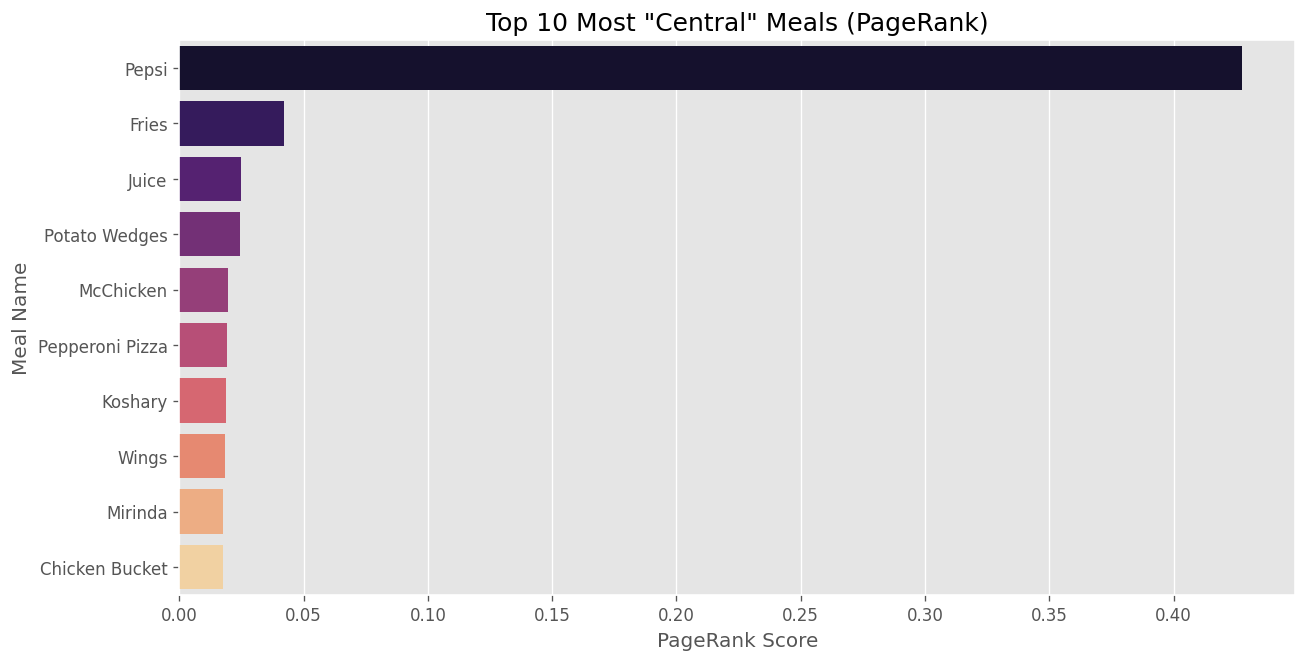

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(x='PageRank_Score', y='Meal', data=pr_df.head(10), palette='magma')

plt.title('Top 10 Most "Central" Meals (PageRank)', fontsize=15)
plt.xlabel('PageRank Score')
plt.ylabel('Meal Name')
plt.show()

#### This creates a horizontal bar chart of the top 10 meals. If the PageRank score of the top meal is significantly higher than the rest, it suggests that the menu is heavily dominated by a few specific items (in this case pepsi).

# Visualizing the Network

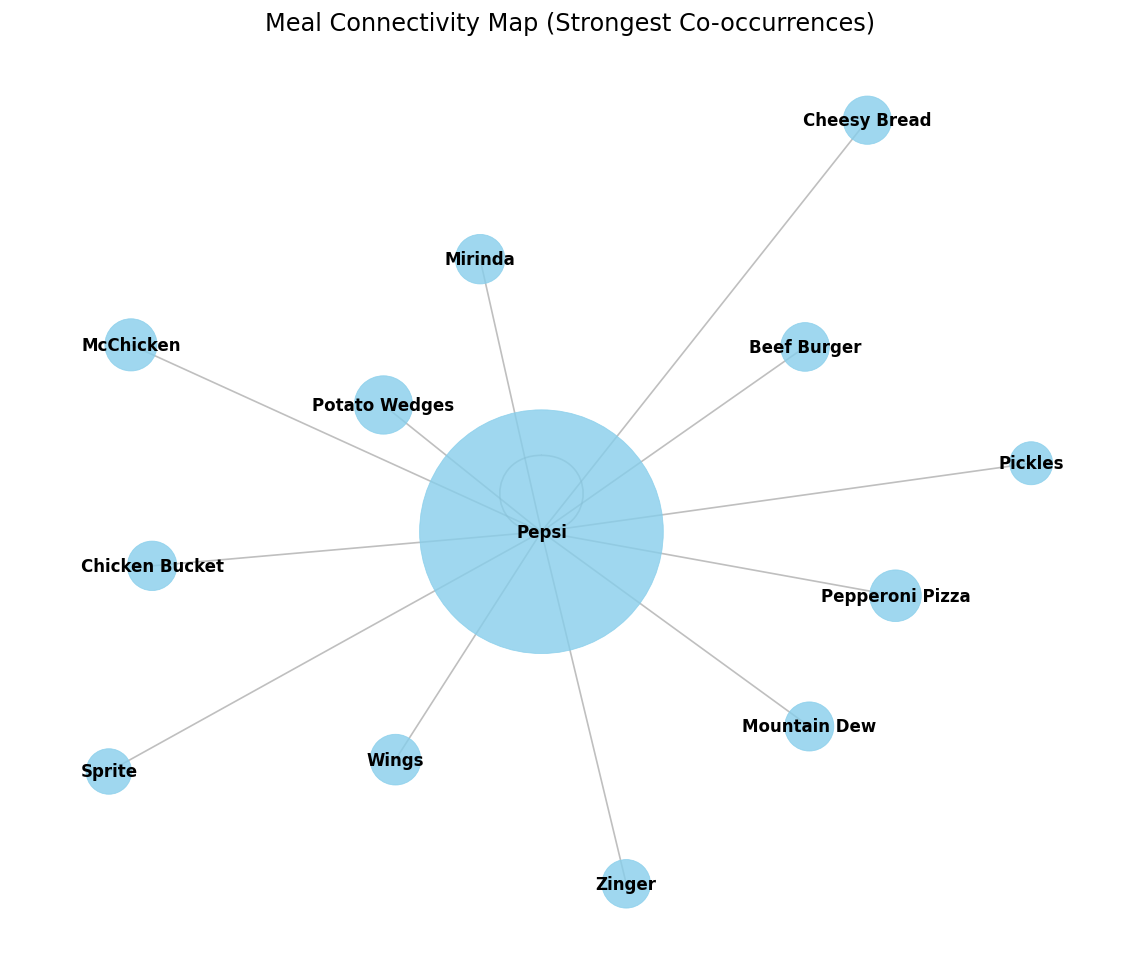

In [12]:
# Since the full graph has 913 edges, we only visualize the strongest connections
# to keep the plot readable.
sub_G = nx.Graph()
for u, v, d in G.edges(data=True):
    if d['weight'] > 5000:  # Only show very strong relationships
        sub_G.add_edge(u, v, weight=d['weight'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(sub_G, k=0.5, seed=42)

# Draw nodes based on PageRank score size
node_sizes = [pagerank_scores[node] * 50000 for node in sub_G.nodes()]

nx.draw_networkx_nodes(sub_G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(sub_G, pos, width=1, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(sub_G, pos, font_size=10, font_weight='bold')

plt.title("Meal Connectivity Map (Strongest Co-occurrences)")
plt.axis('off')
plt.show()

# Business Insights & Recommendations

In [13]:
print(" STRATEGIC MEAL COMBO RECOMMENDATIONS ")
# Find the strongest edge for each of the top 5 PageRank meals
top_meals = pr_df.head(5)['Meal'].tolist()

for meal in top_meals:
    # Look at neighbors and find the one with the highest edge weight
    neighbors = G[meal]
    best_companion = max(neighbors, key=lambda x: neighbors[x]['weight'])
    weight = neighbors[best_companion]['weight']
    
    print(f"Because '{meal}' is a top-ranked item, bundle it with '{best_companion}' (Co-occurred {weight} times).")

 STRATEGIC MEAL COMBO RECOMMENDATIONS 
Because 'Pepsi' is a top-ranked item, bundle it with 'Pepsi' (Co-occurred 621837 times).
Because 'Fries' is a top-ranked item, bundle it with 'Pepsi' (Co-occurred 3032 times).
Because 'Juice' is a top-ranked item, bundle it with 'Fries' (Co-occurred 2283 times).
Because 'Potato Wedges' is a top-ranked item, bundle it with 'Pepsi' (Co-occurred 29068 times).
Because 'McChicken' is a top-ranked item, bundle it with 'Pepsi' (Co-occurred 14688 times).


# Interpretation of PageRank Scores:

#### Unlike raw frequency (which just counts how many times a meal was ordered), PageRank identifies meals that are "central" to the ecosystem. For example, if Pepsi has the highest PageRank, it’s because it’s the bridge between many different types of orders (Burgers, Pizzas, and Pastas). This suggests that Pepsi is the most effective "anchor" for cross-category promotions.